In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlxtend.plotting import heatmap

In [75]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aminasalamt/9000-popular-people-in-cinema")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\zhcri\.cache\kagglehub\datasets\aminasalamt\9000-popular-people-in-cinema\versions\1


In [76]:
df=pd.read_csv("C:/Users/zhcri/.cache/kagglehub/datasets/aminasalamt/9000-popular-people-in-cinema/versions/1/popular_people.csv",)
df.head()


,name,gender,known_for_department,original_name,popularity
0,Eric Larson,2,Visual Effects,Eric Larson,47.9780
1,Robert Middlemass,2,Acting,Robert Middlemass,47.8017
2,María Vaner,1,Acting,María Vaner,47.2016
3,Carl Wharton,2,Acting,Carl Wharton,36.3365
4,Victor Moore,2,Acting,Victor Moore,35.9181


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  9980 non-null   object 
 1   gender                9980 non-null   int64  
 2   known_for_department  9975 non-null   object 
 3   original_name         9980 non-null   object 
 4   popularity            9980 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 390.0+ KB


In [82]:

from sklearn.preprocessing import LabelEncoder
class_le=LabelEncoder()

df_preprocessing=df.values
df_preprocessing[:,2]=class_le.fit_transform(df_preprocessing[:,2])
df_preprocessing_without_nan=df.dropna(subset=["gender", "known_for_department"]).values
df_preprocessing_without_nan[:,2]=class_le.fit_transform(df_preprocessing_without_nan[:,2])


class_mapping = {label: idx for idx, label in enumerate(df['known_for_department'].dropna().unique())}
class_mapping
x=df_preprocessing[:,2]
y=df_preprocessing[:,1]
x_without_nan=df_preprocessing_without_nan[:,2]
y_without_nan=df_preprocessing_without_nan[:,1]
y_without_nan.shape

(9975,)

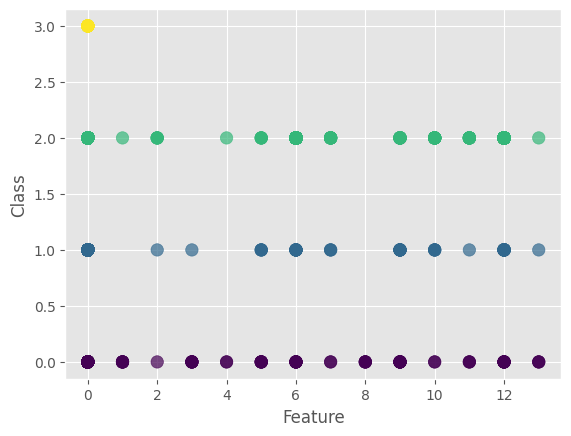

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(x,y,c=y,s=80,alpha=0.7)
plt.style.use('ggplot')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.show()


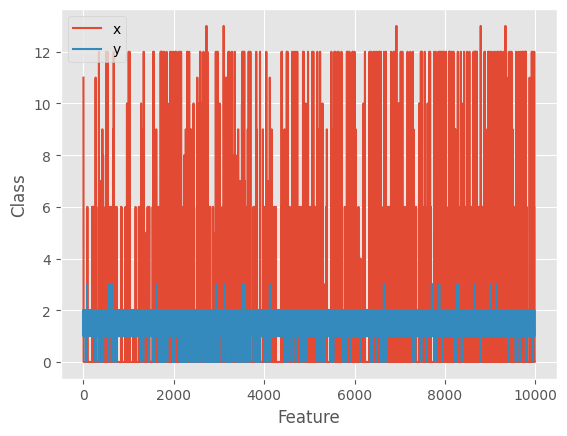

In [ ]:
fig_less_feature,ax_less_feature=plt.subplots()
ax_less_feature.plot(x,label='x')
ax_less_feature.plot(y,label='y')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.legend()
plt.show()

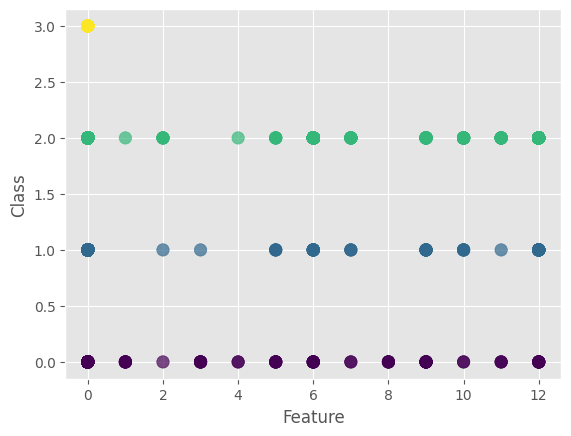

In [ ]:
fig_without_nan, ax_without_nan = plt.subplots()
ax_without_nan.scatter(x_without_nan,y_without_nan,c=y_without_nan,s=80,alpha=0.7)
plt.style.use('ggplot')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0,stratify=y)
lr=OneVsRestClassifier(LogisticRegression(l1_ratio=1,C=1.0,solver='liblinear'))
X_train=X_train.reshape(-1,1)
y_train = y_train.astype(int)
X_test=X_test.reshape(-1,1)
y_test = y_test.astype(int)
lr.fit(X_train,y_train)
lr.score(X_train,y_train)
lr.score(X_test,y_test)
y_pred = lr.predict(X_test)
recall_score(y_test,y_pred,average='micro')
f1_score(y_test,y_pred,average='micro')
precision_score(y_test,y_pred,average='micro')








0.5283901135604543

In [ ]:
from sklearn import svm
sv=svm.SVC(kernel='rbf')
sv.fit(X_train,y_train)
y_pred_svm=sv.predict(X_test)
precision_score(y_test,y_pred_svm,average='micro')
sv_with_ovo=svm.SVC(kernel='linear',decision_function_shape='ovo',C=1.0)
sv_with_ovo.fit(X_train,y_train)
y_pred_svm_with_ovo=sv_with_ovo.predict(X_test)
precision_score(y_test,y_pred_svm_with_ovo,average='micro')





0.5283901135604543

In [ ]:
from sklearn.ensemble import RandomForestClassifier
Forest=RandomForestClassifier(n_estimators=10)
Forest.fit(X_train,y_train)
Forest.score(X_test,y_test)
Forest.score(X_train,y_train)

0.5312052676782135

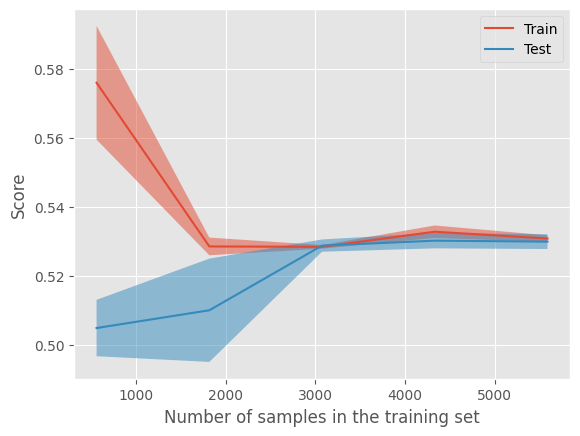

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LearningCurveDisplay, learning_curve
Boosting=GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)
Boosting.fit(X_train,y_train)
Boosting.score(X_test,y_test)
train_sizes, train_scores, test_scores = learning_curve(Boosting,X_train,y_train)
display = LearningCurveDisplay(train_sizes=train_sizes,train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()
plt.show()

In [86]:
X_train, X_test, y_train, y_test = train_test_split(x_without_nan, y_without_nan, test_size=0.3, random_state=0,stratify=y_without_nan)
X_train=X_train.reshape(-1,1)
y_train=y_train.astype(int)
X_test=X_test.reshape(-1,1)
y_test=y_test.astype(int)
Forest.fit(X_train,y_train)
Forest.score(X_test,y_test)
Forest.score(X_train,y_train)

0.5307934689200802